# Analisis 5W+1H - Chicago Crime (Part 2: WHERE)

Bagian ini berfokus pada **WHERE (Di Mana)**, mengeksplorasi lokasi-lokasi utama terjadinya kejahatan, melihat distribusi kejahatan per distrik kepolisian, serta melakukan analisis geospasial pada koordinat kejadian.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Pastikan direktori output ada
OUT = r'c:\Python\Data_Mining\output_5w1h'
os.makedirs(OUT, exist_ok=True)

print("Setup selesai.")

Setup selesai.


In [2]:
# Load data (Fallback ke CSV jika pickle dari proses sebelumnya belum ada)
pickle_path = f'{OUT}/_temp_df.pkl'

if os.path.exists(pickle_path):
    df = pd.read_pickle(pickle_path)
    print(f"Data berhasil dimuat dari pickle: {len(df):,} baris.")
else:
    print("File pickle tidak ditemukan. Memuat dari Mining.csv dan melakukan preprocessing...")
    cols = ['Date','Primary Type','Description','Location Description',
            'Arrest','Domestic','District','Ward','Community Area',
            'Year','Latitude','Longitude','Beat','IUCR','FBI Code','Block']
    df = pd.read_csv(r'c:\Python\Data_Mining\Mining.csv', usecols=cols, nrows=500000, low_memory=False)
    df = df.sample(n=300000, random_state=42).reset_index(drop=True)

    # Feature Engineering yang diperlukan untuk seluruh analisis 5W1H
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    df['Hour'] = df['Date'].dt.hour
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month

    season_map = {12:'Winter',1:'Winter',2:'Winter',
                  3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',
                  9:'Fall',10:'Fall',11:'Fall'}
    df['Season'] = df['Month'].map(season_map)
    df['IsNight'] = df['Hour'].apply(lambda x: 1 if (x >= 22 or x < 6) else 0)
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    severity_map = {'01A':'Kritis','01B':'Kritis',
        '02':'Tinggi','04A':'Tinggi','04B':'Tinggi','03':'Tinggi','15':'Tinggi',
        '05':'Sedang','06':'Sedang','07':'Sedang','09':'Sedang','08A':'Sedang','08B':'Sedang',
        '10':'Rendah','11':'Rendah','14':'Rendah','16':'Rendah','17':'Rendah',
        '18':'Rendah','19':'Rendah','20':'Rendah','22':'Rendah','24':'Rendah','26':'Rendah'}
    df['CrimeSeverity'] = df['FBI Code'].map(severity_map).fillna('Rendah')

    df.to_pickle(pickle_path)
    print(f"Pre-processing selesai. Data disimpan ke pickle. Sample: {len(df):,} rows.")

Data berhasil dimuat dari pickle: 300,000 baris.


---
## OPSI 4: WHERE - Di Mana Kejahatan Terjadi?
---


[4.1] Top 20 Lokasi Kejadian:
   1. STREET                                        94,515
   2. RESIDENCE                                     50,115
   3. APARTMENT                                     24,803
   4. SIDEWALK                                      17,363
   5. OTHER                                         10,308
   6. PARKING LOT/GARAGE(NON.RESID.)                 8,041
   7. ALLEY                                          7,231
   8. SMALL RETAIL STORE                             5,266
   9. RESIDENCE-GARAGE                               5,083
  10. GROCERY FOOD STORE                             4,744
  11. SCHOOL, PUBLIC, BUILDING                       4,718
  12. RESIDENCE PORCH/HALLWAY                        4,670
  13. RESTAURANT                                     4,511
  14. CHA PARKING LOT/GROUNDS                        4,265
  15. DEPARTMENT STORE                               4,135
  16. COMMERCIAL / BUSINESS OFFICE                   3,419
  17. CHA APARTMENT      

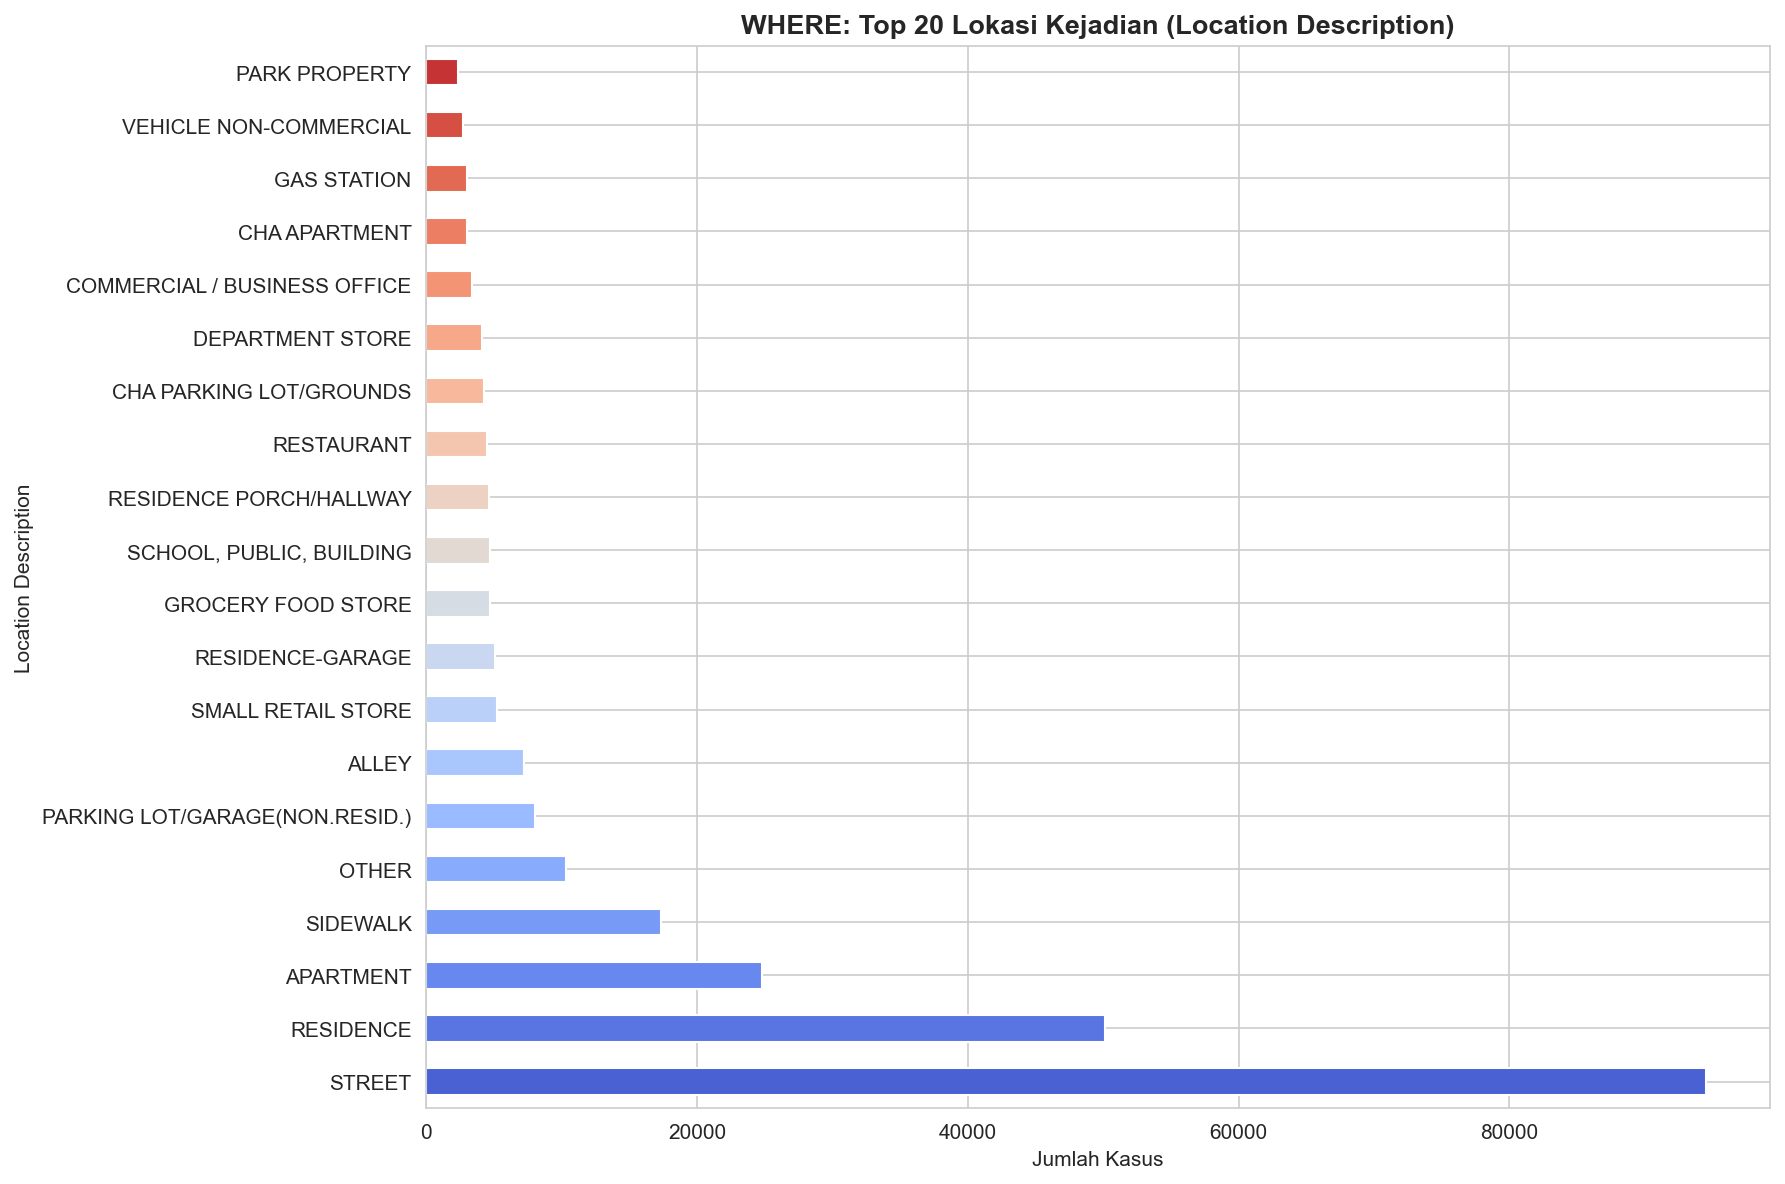

In [3]:
print("\n[4.1] Top 20 Lokasi Kejadian:")
loc_dist = df['Location Description'].value_counts().head(20)
for i, (l, n) in enumerate(loc_dist.items(), 1):
    print(f"  {i:2d}. {str(l):<45s} {n:>6,}")

fig, ax = plt.subplots(figsize=(12, 8))
loc_dist.plot(kind='barh', ax=ax, color=sns.color_palette('coolwarm', 20))
ax.set_title('WHERE: Top 20 Lokasi Kejadian (Location Description)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Kasus')
plt.tight_layout()
plt.savefig(f'{OUT}/where_01_top_locations.png', bbox_inches='tight')
plt.show()


[4.2] Crime per Distrik:


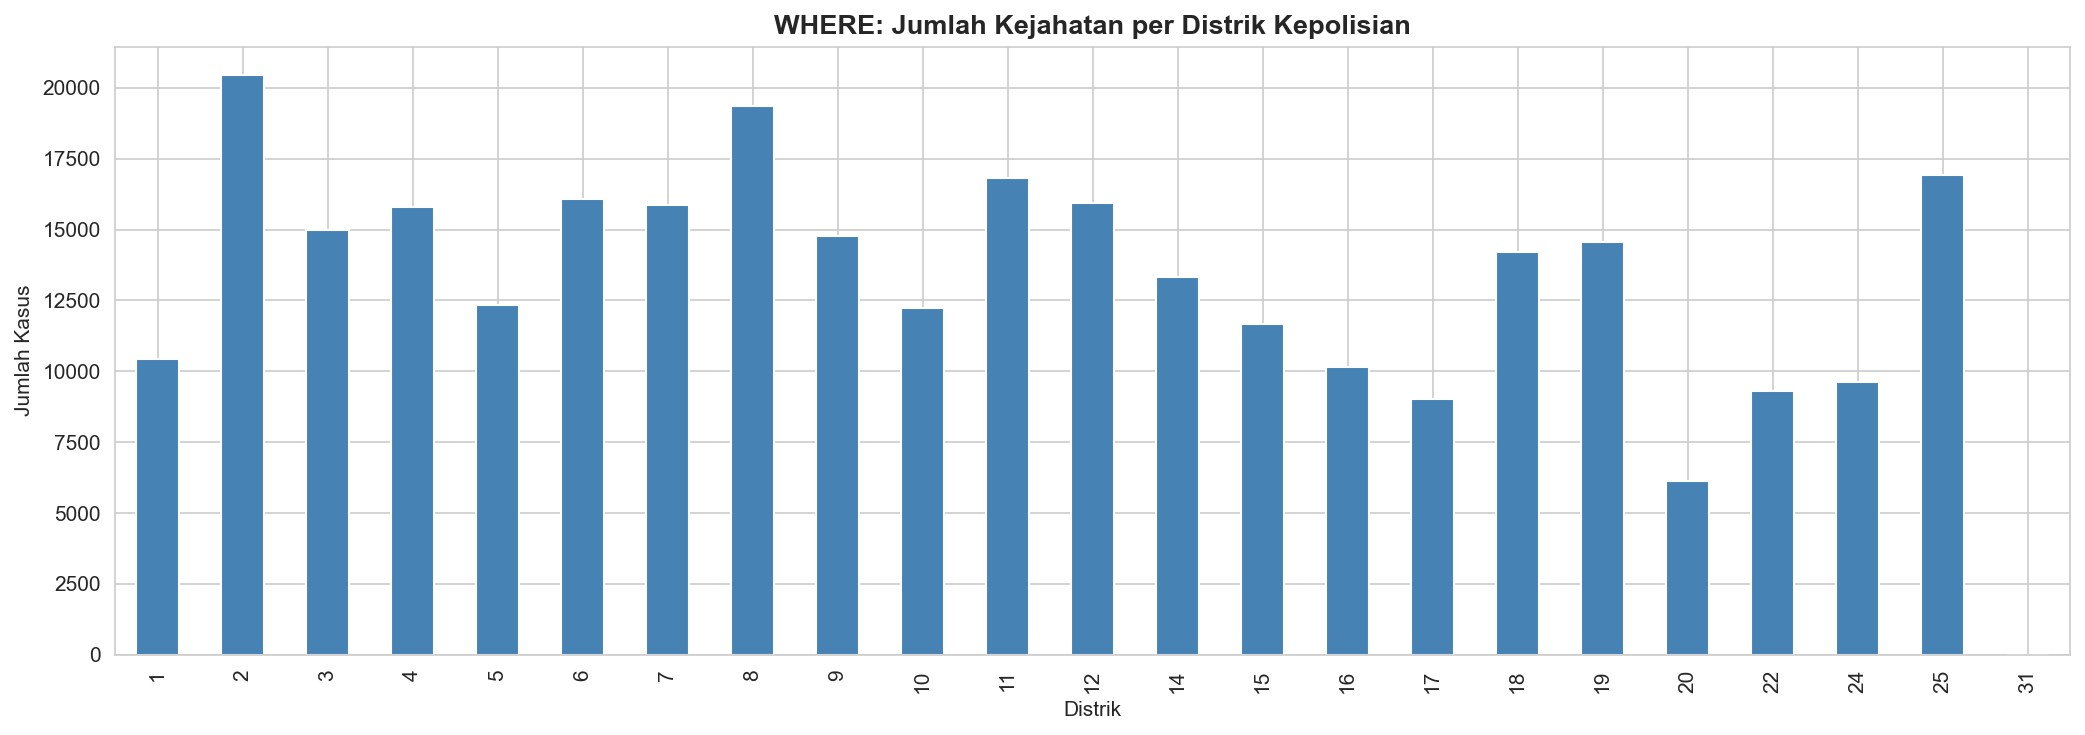

In [4]:
print("\n[4.2] Crime per Distrik:")
dist_crime = df['District'].value_counts().sort_index().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
dist_crime.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('WHERE: Jumlah Kejahatan per Distrik Kepolisian', fontsize=13, fontweight='bold')
ax.set_xlabel('Distrik'); ax.set_ylabel('Jumlah Kasus')
plt.tight_layout()
plt.savefig(f'{OUT}/where_02_district.png', bbox_inches='tight')
plt.show()


[4.3] Heatmap: Crime Type x Location:


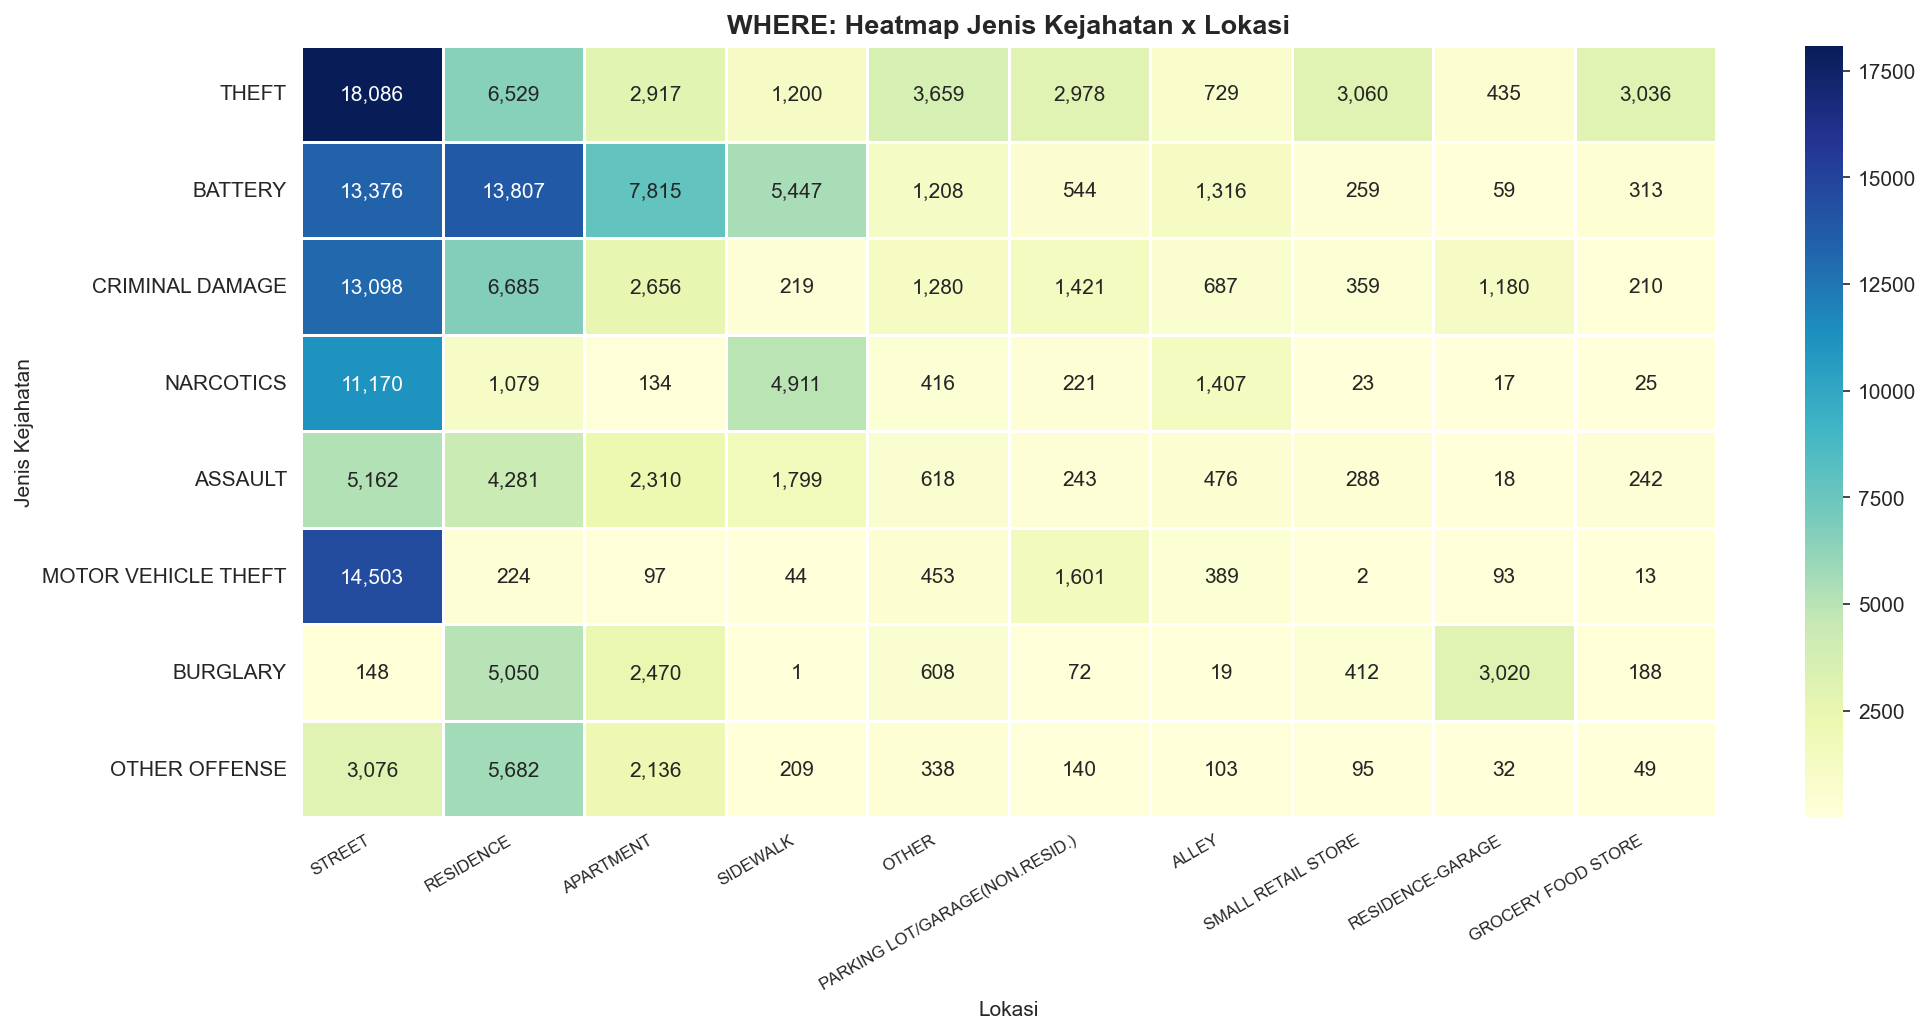

In [5]:
print("\n[4.3] Heatmap: Crime Type x Location:")
top10_loc = df['Location Description'].value_counts().head(10).index
top8_crime = df['Primary Type'].value_counts().head(8).index
ct_loc = pd.crosstab(df[df['Primary Type'].isin(top8_crime)]['Primary Type'],
                      df[df['Location Description'].isin(top10_loc)]['Location Description'])
ct_loc = ct_loc.reindex(index=top8_crime, columns=top10_loc).fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(ct_loc, annot=True, fmt=',.0f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('WHERE: Heatmap Jenis Kejahatan x Lokasi', fontsize=13, fontweight='bold')
ax.set_ylabel('Jenis Kejahatan'); ax.set_xlabel('Lokasi')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUT}/where_03_crime_location_heatmap.png', bbox_inches='tight')
plt.show()


[4.4] Scatter Plot Geospasial:


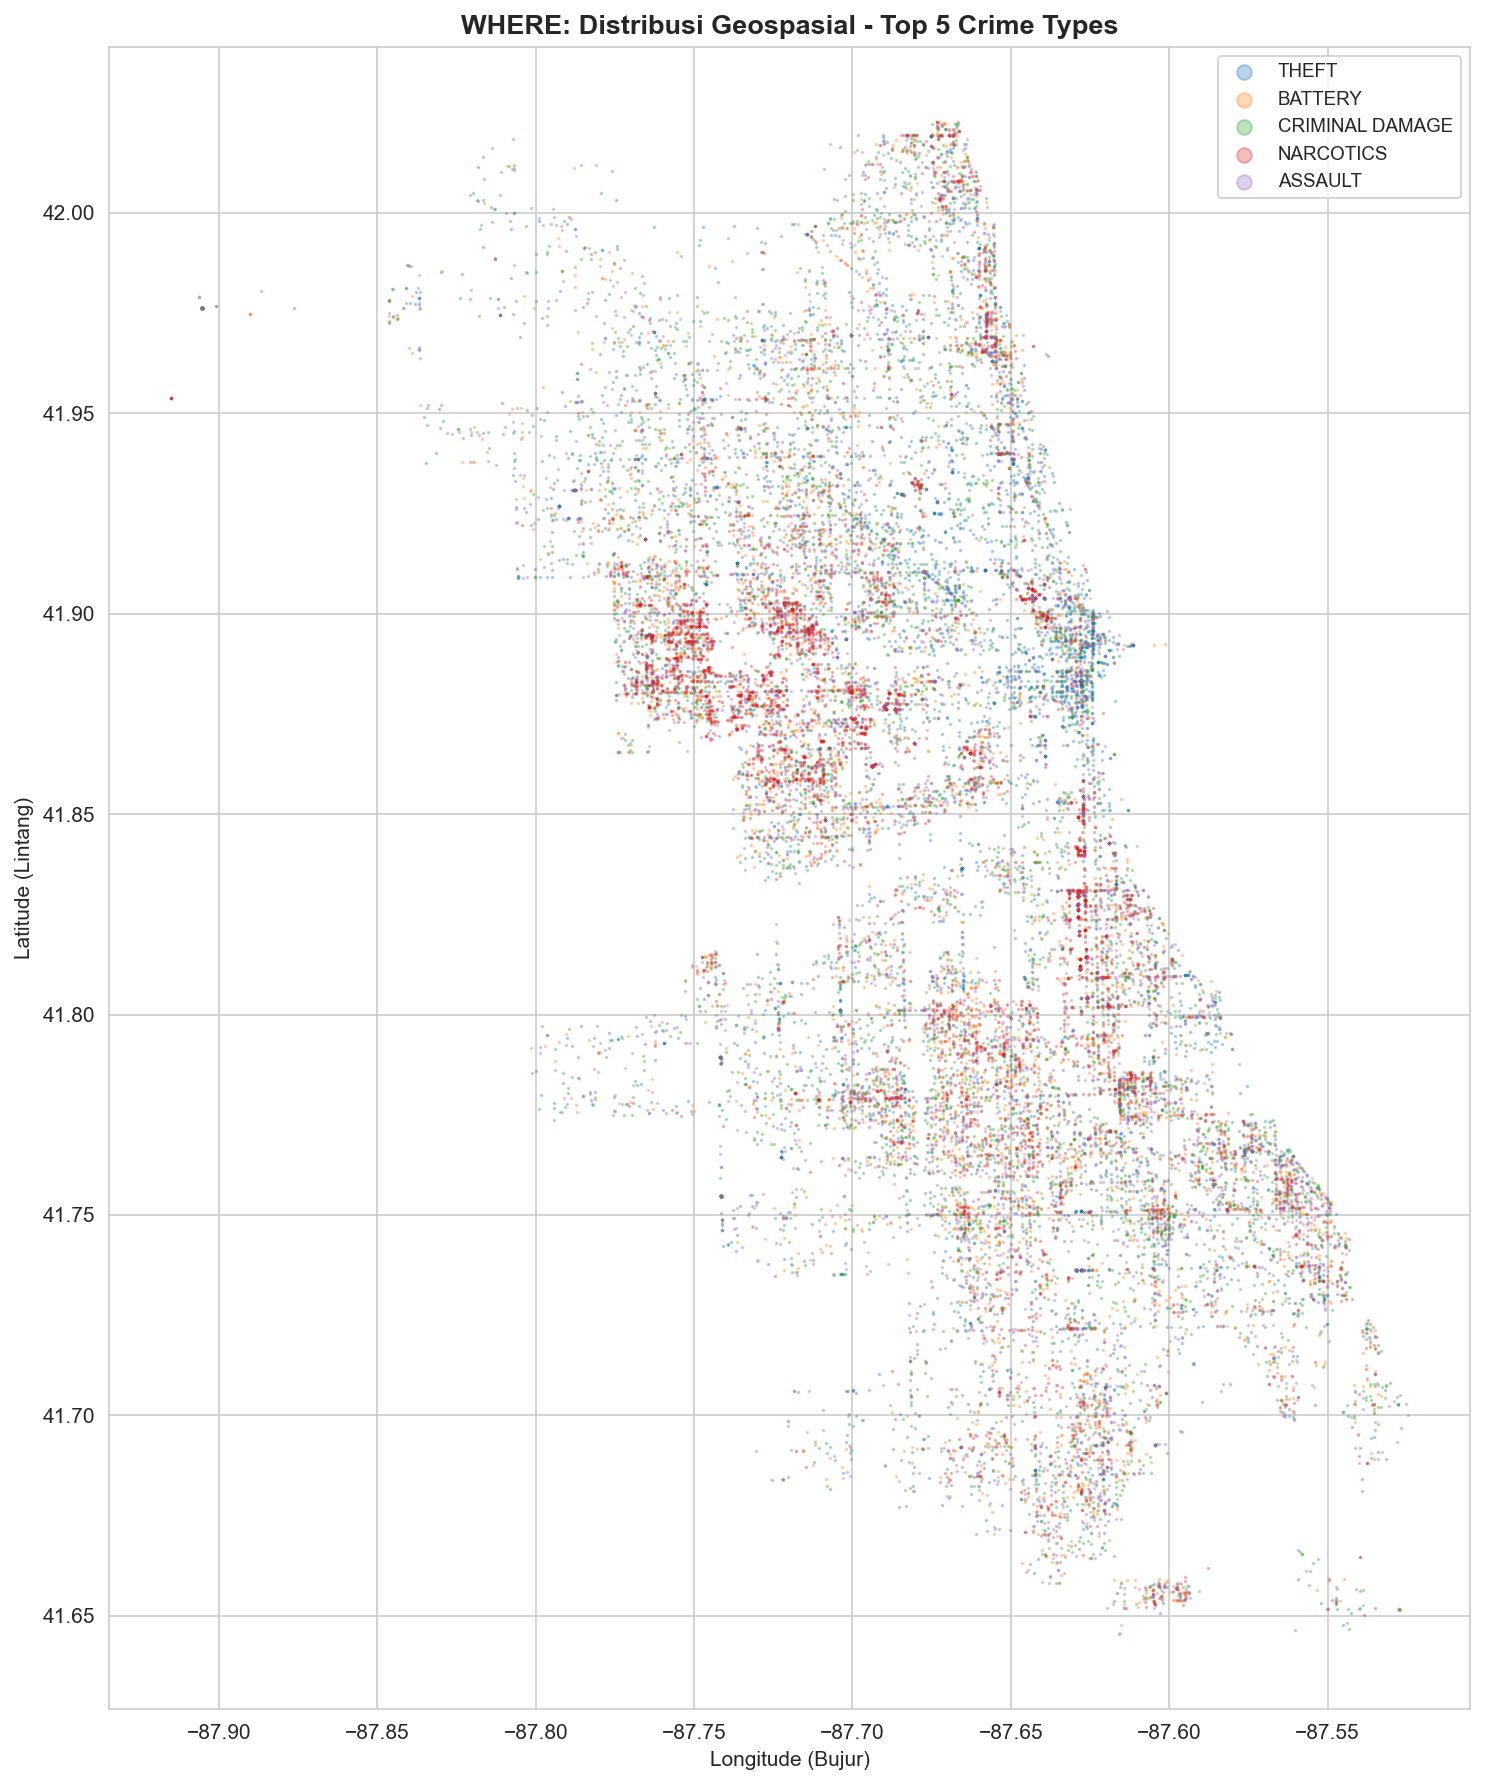

In [6]:
print("\n[4.4] Scatter Plot Geospasial:")
df_geo = df.dropna(subset=['Latitude','Longitude'])
df_geo = df_geo[(df_geo['Latitude'].between(41.6, 42.1)) & 
                (df_geo['Longitude'].between(-87.95, -87.5))]

top5 = df['Primary Type'].value_counts().head(5).index.tolist()

fig, ax = plt.subplots(figsize=(10, 12))
for crime in top5:
    sub = df_geo[df_geo['Primary Type']==crime].sample(min(5000, len(df_geo[df_geo['Primary Type']==crime])), random_state=42)
    ax.scatter(sub['Longitude'], sub['Latitude'], s=0.5, alpha=0.3, label=crime)
ax.set_title('WHERE: Distribusi Geospasial - Top 5 Crime Types', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude (Bujur)'); ax.set_ylabel('Latitude (Lintang)')
ax.legend(markerscale=10, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT}/where_04_geospatial.png', bbox_inches='tight')
plt.show()


[4.5] Arrest Rate per Distrik:


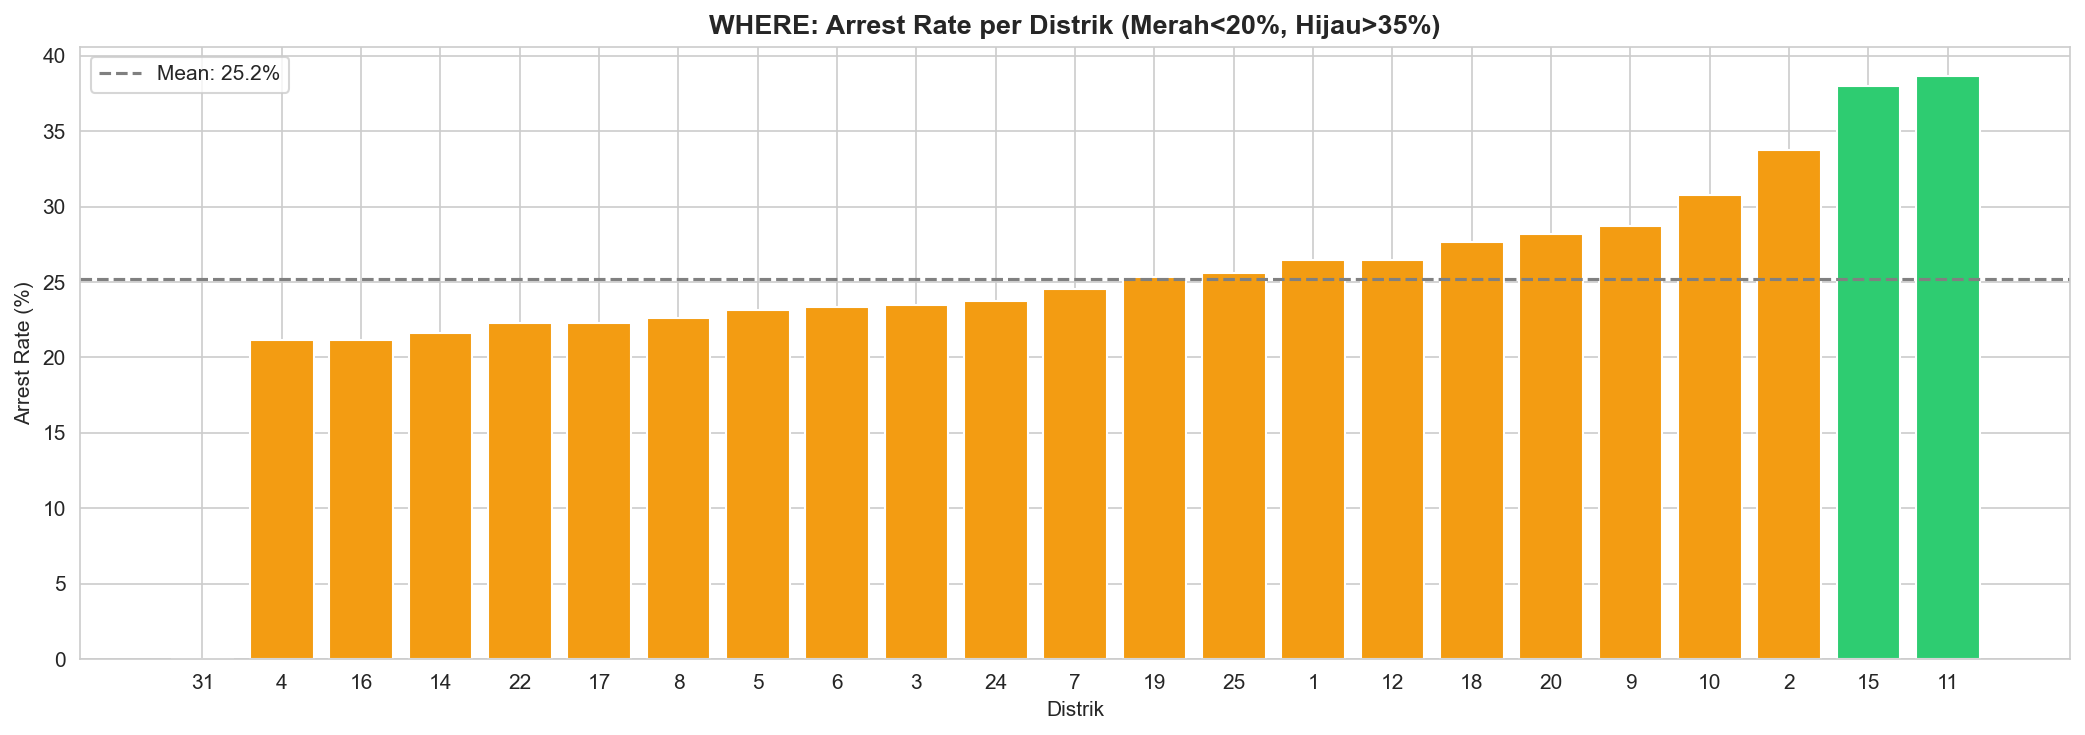

  [Saved] where_01 ~ where_05


In [7]:
print("\n[4.5] Arrest Rate per Distrik:")
dist_ar = df.groupby('District').agg(Total=('Arrest','count'), Arrested=('Arrest','sum'))
dist_ar['Rate'] = dist_ar['Arrested'] / dist_ar['Total'] * 100
dist_ar = dist_ar.sort_values('Rate')

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if r < 20 else '#2ecc71' if r > 35 else '#f39c12' for r in dist_ar['Rate']]
ax.bar(dist_ar.index.astype(str), dist_ar['Rate'], color=colors)
ax.set_title('WHERE: Arrest Rate per Distrik (Merah<20%, Hijau>35%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Distrik'); ax.set_ylabel('Arrest Rate (%)')
ax.axhline(y=dist_ar['Rate'].mean(), color='gray', linestyle='--', label=f'Mean: {dist_ar["Rate"].mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT}/where_05_arrest_district.png', bbox_inches='tight')
plt.show()
print("  [Saved] where_01 ~ where_05")